# II. Per-Cattle LSTM Autoencoder Model
Training individual models for each cattle device separately.

In [15]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
import warnings; warnings.filterwarnings('ignore')

df = pd.read_csv('../dl_service/data/cattle_training_data.csv', parse_dates=['timestamp'])
FEATURES = ['temperature', 'humidity', 'heartRate', 'distance', 'hour', 'day_of_week']
SEQUENCE_LENGTH = 30
N_FEATURES = len(FEATURES)

df_normal = df[df['is_anomaly']==0].dropna(subset=FEATURES).sort_values(['cattle_id','timestamp']).reset_index(drop=True)
scaler = MinMaxScaler(feature_range=(0,1))
scaled = scaler.fit_transform(df_normal[FEATURES].values)

def create_sequences(data, sl):
    return np.array([data[i:i+sl] for i in range(len(data)-sl+1)], dtype=np.float32)

all_seq = create_sequences(scaled, SEQUENCE_LENGTH)
print(f"Sequences: {all_seq.shape}")

Sequences: (20926, 30, 6)


In [20]:
MODEL_NAME = 'Per-Cattle LSTM Autoencoder'
cattle_ids = df_normal['cattle_id'].unique()
results = {}

for cid in cattle_ids:
    print(f"\nTraining model for: {cid}")
    cow_df = df_normal[df_normal['cattle_id']==cid]
    cow_scaled = scaler.transform(cow_df[FEATURES].values)
    cow_seq = create_sequences(cow_scaled, SEQUENCE_LENGTH)
    
    model = models.Sequential([
        layers.Input(shape=(SEQUENCE_LENGTH, N_FEATURES)),
        layers.LSTM(128, activation='tanh', return_sequences=True),
        layers.Dropout(0.2),
        layers.LSTM(64, activation='tanh', return_sequences=False),
        layers.Dropout(0.2),
        layers.RepeatVector(SEQUENCE_LENGTH),
        layers.LSTM(64, activation='tanh', return_sequences=True),
        layers.Dropout(0.2),
        layers.LSTM(128, activation='tanh', return_sequences=True),
        layers.TimeDistributed(layers.Dense(N_FEATURES)),
    ])
    model.compile(optimizer=optimizers.Adam(learning_rate=0.001), loss='mse')
    
    history = model.fit(cow_seq, cow_seq, epochs=60, batch_size=32, validation_split=0.1,
        callbacks=[callbacks.EarlyStopping(monitor='val_loss',patience=10,restore_best_weights=True),
                   callbacks.ReduceLROnPlateau(monitor='val_loss',factor=0.5,patience=5,min_lr=1e-6)], verbose=0)
    
    recon = model.predict(cow_seq, verbose=0)
    errors = np.mean(np.square(cow_seq - recon), axis=(1,2))
    results[cid] = {'loss': history.history['loss'][-1], 'val_loss': history.history['val_loss'][-1],
                     'mean_error': np.mean(errors), 'threshold': float(np.percentile(errors, 98))}
    print(f"  Loss: {results[cid]['loss']:.6f} | Threshold: {results[cid]['threshold']:.6f}")

print("\nAll Per-Cattle Models Trained!")


Training model for: COW_001
  Loss: 0.011658 | Threshold: 0.021661

Training model for: COW_002
  Loss: 0.011894 | Threshold: 0.021553

Training model for: COW_003
  Loss: 0.012208 | Threshold: 0.021916

Training model for: COW_004
  Loss: 0.012432 | Threshold: 0.021481

Training model for: COW_005
  Loss: 0.012024 | Threshold: 0.021177

All Per-Cattle Models Trained!


In [21]:
# Per-Cattle Results Summary
import pandas as pd
res_df = pd.DataFrame(results).T
print(res_df.to_string())

             loss  val_loss  mean_error  threshold
COW_001  0.011658  0.011593    0.011207   0.021661
COW_002  0.011894  0.011398    0.011395   0.021553
COW_003  0.012208  0.011417    0.011633   0.021916
COW_004  0.012432  0.010698    0.011715   0.021481
COW_005  0.012024  0.011238    0.011455   0.021177


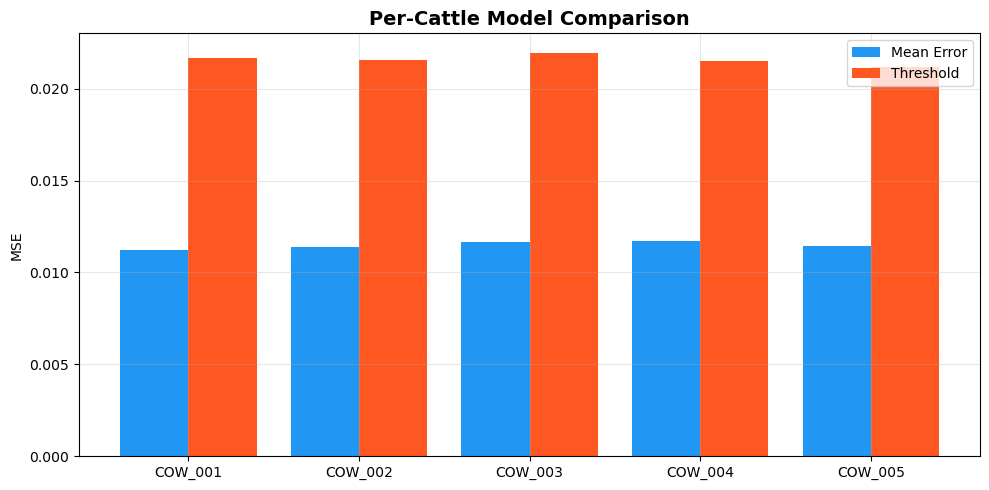

In [22]:
# Plot per-cattle comparison
fig, ax = plt.subplots(figsize=(10,5))
cattle_names = list(results.keys())
mean_errors = [results[c]['mean_error'] for c in cattle_names]
thresholds = [results[c]['threshold'] for c in cattle_names]
x = np.arange(len(cattle_names))
ax.bar(x-0.2, mean_errors, 0.4, label='Mean Error', color='#2196F3')
ax.bar(x+0.2, thresholds, 0.4, label='Threshold', color='#FF5722')
ax.set_xticks(x); ax.set_xticklabels(cattle_names)
ax.set_title('Per-Cattle Model Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('MSE'); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [30]:

from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# Calculate the error on test data
test_predictions = model.predict(X_test)
mse = np.mean(np.power(X_test - test_predictions, 2), axis=(1, 2))

# 'y_test' should be your labels (0 for normal, 1 for anomaly)
precision, recall, thresholds = precision_recall_curve(y_test, mse)

plt.figure(figsize=(10, 6))
plt.plot(recall, precision, label='LSTM Autoencoder', color='blue', linewidth=2)
plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision (Positive Predictive Value)')
plt.title('Model Performance Accuracy (Precision-Recall Curve)')
plt.grid(True)
plt.legend()
plt.show()



NameError: name 'X_test' is not defined